In [2]:
import os
print(os.listdir("models"))  # should list your .pkl files
print(os.listdir("data_curated"))  # should list your CSVs


['global_lstm.h5']
[]


In [6]:
# src/gibbs.py
import joblib, numpy as np, pandas as pd
from tqdm import trange

clf = joblib.load(r"C:\Users\dedee\Downloads\epidemic-project\models\markov_logistic.pkl")
scaler = joblib.load(r"C:\Users\dedee\Downloads\epidemic-project\models\markov_scaler.pkl")
adj = pd.read_csv(r"C:\Users\dedee\Downloads\epidemic-project\data_curated\state_adjacency.csv", index_col=0)


def compute_conditional_prob(state, Z_prev_self, neighbor_states, trend_pred, features_row):
    # build feature vector: [Z_lag1, mean_nb_lag1, trend_pred, daily_tests, daily_vax]
    mean_nb = np.mean([neighbor_states[nb] for nb in neighbor_states]) if neighbor_states else 0
    x = np.array([Z_prev_self, mean_nb, trend_pred, features_row.get('daily_tests',0), features_row.get('daily_vax',0)]).reshape(1,-1)
    x = scaler.transform(x)
    prob = clf.predict_proba(x)[0,1]
    return prob

def gibbs_sample_step(states_order, Z_current, Z_prev, trend_map, features_map, adj):
    # states_order: list of state names shuffled
    for s in states_order:
        nbs = adj.loc[s][adj.loc[s]==1].index.tolist() if s in adj.index else []
        neighbor_states = {nb: Z_current[nb] for nb in nbs}
        prob = compute_conditional_prob(s, Z_prev[s], neighbor_states, trend_map.get(s,0), features_map.get(s,{}))
        Z_current[s] = 1 if np.random.rand() < prob else 0
    return Z_current

def run_gibbs_one_step(Z_prev, trend_map, features_map, adj, n_iter=500, burn_in=200):
    # initialize Z_current with Z_prev (or use trend threshold)
    Z_current = {s: int(Z_prev[s]) for s in Z_prev}
    samples = {s: [] for s in Z_prev}
    states = list(Z_prev.keys())
    for it in range(n_iter):
        np.random.shuffle(states)
        Z_current = gibbs_sample_step(states, Z_current, Z_prev, trend_map, features_map, adj)
        if it >= burn_in:
            for s in states:
                samples[s].append(Z_current[s])
    # compute mean probability per state
    probs = {s: np.mean(samples[s]) if len(samples[s])>0 else Z_prev[s] for s in Z_prev}
    return probs

# Example usage:
# prepare Z_prev dict for all states from last observed day
panel = pd.read_csv(r"C:\Users\dedee\Downloads\epidemic-project\data_curated\panel_state_daily.csv", parse_dates=['Date'])
last_day = panel['Date'].max()
last_rows = panel[panel['Date']==last_day]
Z_prev = dict(zip(last_rows['state'], (last_rows['active']>0).astype(int)))
# trend_map: for each state, get trend predicted by LSTM (normalized active forecast)
# For demo we use simple trend = last day's growth:
trend_map = dict(zip(last_rows['state'], last_rows['active'] - last_rows['active'].shift(1).fillna(0)))
# features_map: daily_tests,daily_vax
features_map = {r: {'daily_tests':int(last_rows[last_rows['state']==r]['daily_tests'].values[0]) if 'daily_tests' in last_rows.columns else 0,
                    'daily_vax':int(last_rows[last_rows['state']==r]['daily_vax'].values[0]) if 'daily_vax' in last_rows.columns else 0}
                for r in last_rows['state']}
probs = run_gibbs_one_step(Z_prev, trend_map, features_map, adj, n_iter=800, burn_in=300)
print("Predicted infection probabilities next day:", probs)


Predicted infection probabilities next day: {'Andaman and Nicobar Islands': np.float64(0.66), 'Andhra Pradesh': np.float64(0.938), 'Arunachal Pradesh': np.float64(0.938), 'Assam': np.float64(0.928), 'Bihar': np.float64(0.962), 'Bihar****': np.float64(0.034), 'Cases being reassigned to states': np.float64(0.034), 'Chandigarh': np.float64(0.934), 'Chhattisgarh': np.float64(0.94), 'Dadra and Nagar Haveli': np.float64(0.04), 'Dadra and Nagar Haveli and Daman and Diu': np.float64(0.888), 'Daman & Diu': np.float64(0.042), 'Delhi': np.float64(0.922), 'Goa': np.float64(0.964), 'Gujarat': np.float64(0.938), 'Haryana': np.float64(0.926), 'Himachal Pradesh': np.float64(0.922), 'Himanchal Pradesh': np.float64(0.034), 'Jammu and Kashmir': np.float64(0.71), 'Jharkhand': np.float64(0.934), 'Karanataka': np.float64(0.034), 'Karnataka': np.float64(0.944), 'Kerala': np.float64(0.92), 'Ladakh': np.float64(0.736), 'Lakshadweep': np.float64(0.758), 'Madhya Pradesh': np.float64(0.938), 'Madhya Pradesh***': 

Bar Plot of Infection Probabilities

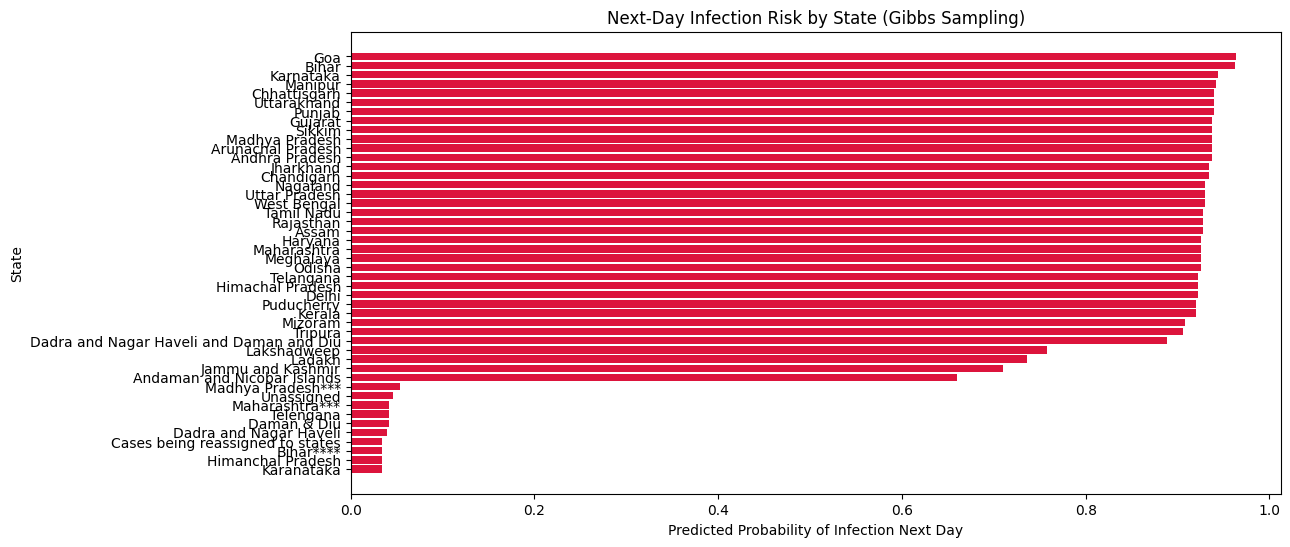

In [7]:
import matplotlib.pyplot as plt

# Convert dict → DataFrame for plotting
probs_df = pd.DataFrame(list(probs.items()), columns=['State', 'Predicted Probability'])
probs_df = probs_df.sort_values('Predicted Probability', ascending=False)

plt.figure(figsize=(12,6))
plt.barh(probs_df['State'], probs_df['Predicted Probability'], color='crimson')
plt.xlabel("Predicted Probability of Infection Next Day")
plt.ylabel("State")
plt.title("Next-Day Infection Risk by State (Gibbs Sampling)")
plt.gca().invert_yaxis()  # highest prob at top
plt.show()
